In [ ]:
# !pip install kagglehub[pandas-datasets]  # -> Utilizar caso dê erro "No module named kagglehub"

### **Heart Failure Prediction** (Previsão de Insuficiência Cardíaca)


---

### 1. Escolha do Dataset
* **Contexto**

  As doenças cardiovasculares (DCV) são a principal causa de morte em todo o mundo, ceifando cerca de 17,9 milhões de vidas por ano, o que representa 31% de todas as mortes no mundo. Quatro em cada cinco mortes por DCV são causadas por ataques cardíacos e acidentes vasculares cerebrais, e um terço dessas mortes ocorre prematuramente em pessoas com menos de 70 anos de idade. A insuficiência cardíaca é um evento comum causado por DCV e este conjunto de dados contém 11 características que podem ser usadas para prever uma possível doença cardíaca.

  Pessoas com doença cardiovascular ou que apresentam alto risco cardiovascular (devido à presença de um ou mais fatores de risco, como hipertensão, diabetes, hiperlipidemia ou doença já estabelecida) precisam de deteção e tratamento precoces, nos quais um modelo de aprendizagem automática pode ser de grande ajuda.

  O dataset está hospedado no link https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

---

* **Fonte dos dados**

  Este conjunto de dados foi criado através da combinação de diferentes conjuntos de dados já disponíveis independentemente. Neste conjunto de dados, cinco conjuntos de dados cardíacos são combinados em 11 características comuns, o que o torna o maior conjunto de dados sobre doenças cardíacas disponível até agora para fins de investigação. Os cinco conjuntos de dados utilizados para a sua curadoria são:


    Cleveland: 303 observações

    Húngaro: 294 observações

    Suíça: 123 observações

    Long Beach VA: 200 observações

    Conjunto de dados Stalog (coração): 270 observações

    Total: 1190 observações

    Duplicadas: 272 observações

    Totalizando: 918 observações

---

In [ ]:
# Importa a biblioteca pandas, usada para manipulação e análise de dados estruturados (DataFrames e Séries).
import pandas as pd

# Importa a biblioteca NumPy, essencial para computação numérica e manipulação de arrays multidimensionais.
import numpy as np

# Importa as bibliotecas de Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
path = 'heart.csv'

# Load the latest version
df = kagglehub.dataset_load(
  adapter=KaggleDatasetAdapter.PANDAS,
  handle="fedesoriano/heart-failure-prediction",
  path=path
)

df.head(10)

100%|██████████| 35.1k/35.1k [00:00<00:00, 24.3MB/s]


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [ ]:
# Tradução dos nomes de colunas para o Português do Brasil
df_pt = df.copy()

df_pt = df_pt.rename(columns={
    'Age': 'Idade',
    'Sex': 'Sexo',
    'ChestPainType': 'TipoDorPeito',
    'RestingBP': 'PressaoArterialRepouso',
    'Cholesterol': 'Colesterol',
    'FastingBS': 'GlicoseJejum',
    'RestingECG': 'ECGRepouso',
    'MaxHR': 'FrequenciaCardiacaMaxima',
    'ExerciseAngina': 'AnginaExercicio',
    'Oldpeak': 'Oldpeak', # This term is often kept in English
    'ST_Slope': 'InclinacaoST',
    'HeartDisease': 'DoencaCardiaca'
    })
display(df_pt.head(10))

,Idade,Sexo,TipoDorPeito,PressaoArterialRepouso,Colesterol,GlicoseJejum,ECGRepouso,FrequenciaCardiacaMaxima,AnginaExercicio,Oldpeak,InclinacaoST,DoencaCardiaca
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


### 2. Descrição do DataSet


| Coluna | Descrição | Tipo de Dado | Observações |
| :--- | :--- | :--- | :--- |
| **Age** | Idade do paciente em anos. | Numérico | |
| **Sex** | Sexo do paciente ('M' para Masculino, 'F' para Feminino). | Categórico Nominal| |
| **ChestPainType** | Tipo de dor no peito. | Categórico Ordinal | `TA`: Angina Típica<br>`ATA`: Angina Atípica<br>`NAP`: Dor Não Anginosa<br>`ASY`: Assintomático |
| **RestingBP** | Pressão arterial em repouso (em mm Hg). | Qualitativa Discreta | **Atenção:** Valores `0` são erros e precisam ser tratados. |
| **Cholesterol** | Nível de colesterol (em mg/dl). | Quantitativa Discreta | **Atenção:** Valores `0` são erros e precisam ser tratados. |
| **FastingBS** | Nível de açúcar no sangue em jejum. | Categórico (Binário) | `1`: se for > 120 mg/dl<br>`0`: caso contrário |
| **RestingECG** | Resultados do eletrocardiograma em repouso. | Categórico | `Normal`: Normal<br>`ST`: Anormalidade da onda ST-T<br>`LVH`: Hipertrofia ventricular esquerda |
| **MaxHR** | Frequência cardíaca máxima atingida durante teste de esforço. | Quantitativa Discreta | |
| **ExerciseAngina**| Angina (dor no peito) induzida por exercício. | Categórico (Binário) | `Y`: Sim<br>`N`: Não |
| **Oldpeak** | Depressão do segmento ST induzida pelo exercício. | Quantitativa Contínua | Mede a diferença no eletrocardiograma entre o repouso e o esforço. |
| **ST_Slope** | A inclinação do pico do segmento ST no exercício. | Categórico Nominal | `Up`: Ascendente<br>`Flat`: Plana<br>`Down`: Descendente |
| **HeartDisease** | **Variável-Alvo (O que queremos prever)** | Categórica Nominal | `1`: Tem doença cardíaca<br>`0`: Não tem doença cardíaca |


---

  * **Sobre a variável** Tipo dor no peito:

  Existe uma ordenação nas sigla no que diz respeito a probabilidade de ser uma dor de origem cardíaca.

        1. TA: Angina Típica

            A angina típica (TA) representa a maior probabilidade.
        2. ATA: Angina Atípica

            A angina atípica (ATA) representa probabilidade intermediária.

        3. NAP: Dor Não Anginosa

            A dor não anginosa (NAP) representa probabilidade baixa.

        4. ASY: Assintomático

            Estar assintomático (ASY) não apresentar dor no peito ou qualquer outro sintoma relacionado à isquemia.
  Desta forma está variável categórica deve ser tratada como ordinal.

 ### Problema  
* **Objetivo Principal:** Criar um modelo de **classificação binária**. Que deve aprender com os dados desse dataset e ser capaz de prever com a entrada de novos dados uma de duas opções:
  * `1`: O paciente tem doença cardíaca.
  * `0`: O paciente não tem doença cardíaca.
* **Tamanho:** Contém 918 registros (pacientes) e 12 colunas (11 características do paciente + 1 coluna de resultado).
* **O tipo de modelo modelo de apredizado será de:** Classificação.

---

### 3. Pré-processamento

Antes de usar os dados em um modelo, é preciso "limpá-los":

1. **Codificar Variáveis Categóricas:** Modelos de machine learning não entendem texto ('M', 'F', 'Normal', etc.). É preciso converter tudo para números.
    * **Ação:** Usar a técnica de **One-Hot Encoding**. Ela cria novas colunas binárias (0 ou 1) para cada categoria (ex: `Sex_M`, `Sex_F`).

2. **Normalizar os Dados Numéricos (Feature Scaling):** Variáveis como `Age` (ex: 28 a 77) e `Colesterol` (ex: 85 a 603) estão em escalas muito diferentes. Isso pode atrapalhar o desempenho de alguns modelos.
    * **Ação:** Usar um normalizador como o `StandardScaler` para colocar todas as variáveis numéricas em uma escala semelhante.
3. **Necessidade de tradução do inglês para o portugues:**
    * Aplicação de renomeamento nas colulas para traduzir ajundando na compreenssão das variáveis e seos valores.
---

### 4. Estatística Descritiva

Uma análise rápida dos dados já revela padrões muito fortes:

* **Distribuição da Doença:** O dataset é bem balanceado, com aproximadamente 55% dos pacientes tendo doença cardíaca e 45% não tendo. Isso é ótimo para treinar um modelo.
* **Preditores Mais Fortes:**
  * **ST_Slope (Inclinação ST):** Pacientes com inclinação `Flat` (Plana) ou `Down` (Descendente) têm uma chance altíssima de ter doença cardíaca. Uma inclinação `Up` (Ascendente) é um forte sinal de saúde.
  * **ChestPainType (Tipo de Dor no Peito):** Pacientes **assintomáticos** (`ASY`) são, de longe, os mais propensos a ter doença cardíaca. Isso pode parecer contraintuitivo, mas clinicamente faz sentido (isquemia silenciosa é um grande fator de risco).
  * **ExerciseAngina (Angina por Exercício):** Sentir dor no peito durante o exercício (`Y`) é um indicador muito forte de doença cardíaca.
  * **MaxHR (Frequência Cardíaca Máxima):** Pessoas com doença cardíaca tendem a atingir uma frequência cardíaca máxima mais baixa durante o esforço.
  * **Age (Idade):** A idade média dos pacientes com doença cardíaca é significativamente maior.

---

In [ ]:
# Tabela com as contagens de zeros
contagem_zeros_Colesterol = (df_pt['Colesterol'] == 0).sum()
contagem_zeros_PressaoArterialRepouso = (df_pt['PressaoArterialRepouso'] == 0).sum()
# Cria um dicionário com as contagens de zeros para as colunas relevantes
dados_zeros = {
  'Atributo': ['Colesterol', 'PressaoArterialRepouso'],
  'Contagem de Zeros': [contagem_zeros_Colesterol, contagem_zeros_PressaoArterialRepouso]
}

# Cria o DataFrame a partir do dicionário
tabela_zeros = pd.DataFrame(dados_zeros)

# Imprime a tabela
print("\nTabela de Contagem de Zeros:")
tabela_zeros


Tabela de Contagem de Zeros:


,Atributo,Contagem de Zeros
0,Colesterol,172
1,PressaoArterialRepouso,1


In [ ]:
# Informações do data set
df_pt.info()
# Estatística descritiva
df_pt.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Idade                     918 non-null    int64  
 1   Sexo                      918 non-null    object 
 2   TipoDorPeito              918 non-null    object 
 3   PressaoArterialRepouso    918 non-null    int64  
 4   Colesterol                918 non-null    int64  
 5   GlicoseJejum              918 non-null    int64  
 6   ECGRepouso                918 non-null    object 
 7   FrequenciaCardiacaMaxima  918 non-null    int64  
 8   AnginaExercicio           918 non-null    object 
 9   Oldpeak                   918 non-null    float64
 10  InclinacaoST              918 non-null    object 
 11  DoencaCardiaca            918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Idade,PressaoArterialRepouso,Colesterol,GlicoseJejum,FrequenciaCardiacaMaxima,Oldpeak,DoencaCardiaca
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Como a máquina não compreende palavras, vamos transformar em números os atributos cujos valores são palavras, siglas e etc.

In [ ]:
# Encodando os atributos com valores em string

df_pt['Sexo'] = df_pt['Sexo'].map({'M': 0, 'F': 1})
df_pt['AnginaExercicio'] = df_pt['AnginaExercicio'].map({'Y': 1, 'N': 0})

# Os tipos de dores no peito estão classificados como Qualit. Nominal, porém, de acordo com a literatura
# cada tipo de dor implica num nível de agravante maior, logo, é ORDINAL.
df_pt['TipoDorPeito'] = df_pt['TipoDorPeito'].map({'TA': 3, 'ATA': 2, 'NAP': 1, 'ASY': 0})
df_pt['ECGRepouso'] = df_pt['ECGRepouso'].map({'Normal': 0, 'ST': 1, 'LVH': 2})

# Para a inclinação do pico do segmento da onda ST do eletrocardiograma durante exercício, também temos uma ordem de agravante
# Onde as chances da pessoa estar doente com ST ascendente são as menores dentre todas, seguidas da descendente, com chances
# maiores e, por fim, a plana, que é a que apresenta a maior quantidade de pacientes com insuficiência cardíaca
df_pt['InclinacaoST'] = df_pt['InclinacaoST'].map({'Up': 0, 'Down': 1, 'Flat': 2})

df_pt.head(11)

,Idade,Sexo,TipoDorPeito,PressaoArterialRepouso,Colesterol,GlicoseJejum,ECGRepouso,FrequenciaCardiacaMaxima,AnginaExercicio,Oldpeak,InclinacaoST,DoencaCardiaca
0,40,0,2,140,289,0,0,172,0,0.0,0,0
1,49,1,1,160,180,0,0,156,0,1.0,2,1
2,37,0,2,130,283,0,1,98,0,0.0,0,0
3,48,1,0,138,214,0,0,108,1,1.5,2,1
4,54,0,1,150,195,0,0,122,0,0.0,0,0
5,39,0,1,120,339,0,0,170,0,0.0,0,0
6,45,1,2,130,237,0,0,170,0,0.0,0,0
7,54,0,2,110,208,0,0,142,0,0.0,0,0
8,37,0,0,140,207,0,0,130,1,1.5,2,1
9,48,1,2,120,284,0,0,120,0,0.0,0,0


### Aplicando o $\chi^2$ para as variáveis categóricas

In [ ]:

from scipy.stats import chi2_contingency

#Traça target e variáveis qualitativas
variaveis = ['AnginaExercicio','ECGRepouso','Sexo','TipoDorPeito','InclinacaoST', 'GlicoseJejum']
target = 'DoencaCardiaca'

results = list()
#Para cada variável constroi a tabela cruzada, tabela esperada e calcula o qui-quadrado, e tira conclusão
for var in variaveis:
    tabela = pd.crosstab(df_pt[var], df_pt[target])
    chi2_result, p_value, dof, expected = chi2_contingency(tabela)

    total_patients = int(df_pt[var].count())
    contingency_coefficient = chi2_result / (chi2_result + total_patients)

    print(f"\n Variável: {var}")
    print("Tabela Observada:")
    display(tabela)
    print("Tabela Esperada:")
    display(pd.DataFrame(expected, index=tabela.index, columns=tabela.columns))
    print(f"Chi² = {chi2_result:.4f}, p-valor = {p_value:.4f}, DoF = {dof}")

    #Verificação do p-valor para descartar ou não a Hipotese Nula (H0)
    if p_value < 0.05:
        print("Existe evidência estatística de dependência entre as variáveis.")
    else:
        print("Não há evidência estatística de dependência entre as variáveis.")

    results.append((var, contingency_coefficient*100))


 Variável: AnginaExercicio
Tabela Observada:


DoencaCardiaca,0,1
AnginaExercicio,,
0,355,192
1,55,316


Tabela Esperada:


DoencaCardiaca,0,1
AnginaExercicio,,
0,244.302832,302.697168
1,165.697168,205.302832


Chi² = 222.2594, p-valor = 0.0000, DoF = 1
Existe evidência estatística de dependência entre as variáveis.

 Variável: ECGRepouso
Tabela Observada:


...

Chi² = 355.9184, p-valor = 0.0000, DoF = 2
Existe evidência estatística de dependência entre as variáveis.

 Variável: GlicoseJejum
Tabela Observada:


DoencaCardiaca,0,1
GlicoseJejum,,
0,366,338
1,44,170


Tabela Esperada:


DoencaCardiaca,0,1
GlicoseJejum,,
0,314.422658,389.577342
1,95.577342,118.422658


Chi² = 64.3207, p-valor = 0.0000, DoF = 1
Existe evidência estatística de dependência entre as variáveis.


In [ ]:
qui_quadrado = pd.DataFrame(results, columns=['Attr. Qualit.', 'Chi-Quadrado_Coef-Conting'])
qui_quadrado = qui_quadrado.sort_values(by='Chi-Quadrado_Coef-Conting', ascending=False)
qui_quadrado

,Attr. Qualit.,Chi-Quadrado_Coef-Conting
4,InclinacaoST,27.938872
3,TipoDorPeito,22.601353
0,AnginaExercicio,19.492002
2,Sexo,8.396499
5,GlicoseJejum,6.547829
1,ECGRepouso,1.176779


### Vamos tratar os dados faltantes mostrados anteriormente:
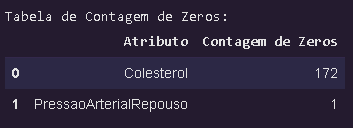

In [ ]:
# Tratando o valor errante de "PressaoArterialRepouso"
df_pt.loc[df_pt['PressaoArterialRepouso'] == 0, 'PressaoArterialRepouso'] = df_pt['PressaoArterialRepouso'].median()
(df_pt[['PressaoArterialRepouso']] == 0).sum()  # Somatório das instâncias em que PressaoArterialRepouso é igual a zero

,0
PressaoArterialRepouso,0


In [ ]:
# Analisando os recortes da idade onde Colesterol é zero e onde colesterol não é zero
df_pt.loc[df_pt['Colesterol'] == 0, 'Idade'].describe()

,Idade
count,172.000000
mean,56.238372
std,8.616327
min,32.000000
25%,51.750000
50%,57.500000
75%,62.000000
max,74.000000


In [ ]:
meancol32 = df_pt.loc[df_pt['Idade'] == 32, 'Colesterol'].mean()
meancol52 = df_pt.loc[df_pt['Idade'] == 52, 'Colesterol'].mean()
meancol62 = df_pt.loc[df_pt['Idade'] == 62, 'Colesterol'].mean()
meancol57 = df_pt.loc[df_pt['Idade'] == 57, 'Colesterol'].mean()
meancol74 = df_pt.loc[df_pt['Idade'] == 74, 'Colesterol'].mean()

print(
    f"Média Colesterol aos 32 anos de idade: {meancol32}\n" +
    f"Média Colesterol aos 52 anos de idade: {meancol52}\n" +
    f"Média Colesterol aos 62 anos de idade: {meancol62}\n" +
    f"Média Colesterol aos 57 anos de idade: {meancol57}\n" +
    f"Média Colesterol aos 74 anos de idade: {meancol74}"
)

Média Colesterol aos 32 anos de idade: 241.2
Média Colesterol aos 52 anos de idade: 200.27777777777777
Média Colesterol aos 62 anos de idade: 166.74285714285713
Média Colesterol aos 57 anos de idade: 202.31578947368422
Média Colesterol aos 74 anos de idade: 184.28571428571428


In [ ]:
meancol32 = int(meancol32)
meancol52 = int(meancol52)
meancol62 = int(meancol62) + 1
meancol57 = int(meancol57)
meancol74 = int(meancol74)

In [ ]:
# Fazendo o tratamento dos valores faltantes de "Colesterol"

df_pt.loc[(df_pt['Idade'] == 74) & (df_pt['Colesterol'] == 0), 'Colesterol'] = meancol74
df_pt.loc[(df_pt['Idade'] == 32) & (df_pt['Colesterol'] == 0), 'Colesterol'] = meancol32
df_pt.loc[(df_pt['Idade'] == 52) & (df_pt['Colesterol'] == 0), 'Colesterol'] = meancol52
df_pt.loc[(df_pt['Idade'] == 62) & (df_pt['Colesterol'] == 0), 'Colesterol'] = meancol62
df_pt.loc[(df_pt['Idade'] == 57) & (df_pt['Colesterol'] == 0), 'Colesterol'] = meancol57

df_pt.loc[df_pt['Colesterol'] == 0, 'Colesterol'] = int(df_pt['Colesterol'].median())

(df_pt[['Colesterol']] == 0).sum()

,0
Colesterol,0


### Ótimo! Tendo os dados errantes tratados, podemos seguir para o próximo passo e analisar quais são os melhores atributos preditores da variável-alvo por medidas estatísticas de relação e então comparar com os melhores atributos à partir do método SelectKBest da biblioteca do Sickit-Learn.

### Como o $\mathrm{\chi^2}$ já foi calculado para as variáveis qualitativas, vamos calcular o $\mathbf{R^2}$ para as variáveis quantitativas.

In [ ]:
# Dicionário para guardar os escores-R2
r2_scores = {}
# variável-alvo
var_alvo = 'DoencaCardiaca'

In [ ]:
# Atributo que se quer checar a associação com a alvo
var_att = 'PressaoArterialRepouso'

# Calcular SQE com base na variância dentro dos grupos (não explicada)
variancia_intra_grupos = df_pt.groupby(var_alvo)[var_att].var()  # Variância intra-grupos
frequencia_por_grupo = df_pt[var_alvo].value_counts()  # Frequência por grupo
SQE = (variancia_intra_grupos * frequencia_por_grupo).sum()  # Soma ponderada das variâncias intra-grupos

# Calcular a média geral das notas em Estatística
media_geral = df_pt[var_att].mean()

# SQT já calculado anteriormente (Soma dos Quadrados Total)
SQT = ((df_pt[var_att] - media_geral) ** 2).sum()

# Calcular R^2
R2 = SQE / SQT

# Calcular R^2 com a fórmula revisada
R2_revisado = 1 - (SQE / SQT)

# Exibir os resultados revisados

print(f"Média Geral: {round(media_geral, 4)}")
print(f"Soma dos Quadrados Total (SQT): {round(SQT, 4)}")
print(f"Soma dos Quadrados Explicada (SQE): {round(SQE, 4)}")
print(f"Coeficiente de Determinação (R^2): {round(R2, 4)}")
print(f"Coeficiente de Determinação Revisado (R^2):{round(R2_revisado, 4)}")

r2_scores[var_att] = R2_revisado*100

Média Geral: 132.5381
Soma dos Quadrados Total (SQT): 296782.1656
Soma dos Quadrados Explicada (SQE): 293293.7402
Coeficiente de Determinação (R^2): 0.9882
Coeficiente de Determinação Revisado (R^2):0.0118


In [ ]:
# Atributo que se quer checar a associação com a alvo
var_att = 'FrequenciaCardiacaMaxima'

# Calcular SQE com base na variância dentro dos grupos (não explicada)
variancia_intra_grupos = df_pt.groupby(var_alvo)[var_att].var()  # Variância intra-grupos
frequencia_por_grupo = df_pt[var_alvo].value_counts()  # Frequência por grupo
SQE = (variancia_intra_grupos * frequencia_por_grupo).sum()  # Soma ponderada das variâncias intra-grupos

# Calcular a média geral das notas em Estatística
media_geral = df_pt[var_att].mean()

# SQT já calculado anteriormente (Soma dos Quadrados Total)
SQT = ((df_pt[var_att] - media_geral) ** 2).sum()

# Calcular R^2
R2 = SQE / SQT

# Calcular R^2 com a fórmula revisada
R2_revisado = 1 - (SQE / SQT)

# Exibir os resultados revisados

print(f"Média Geral: {round(media_geral, 4)}")
print(f"Soma dos Quadrados Total (SQT): {round(SQT, 4)}")
print(f"Soma dos Quadrados Explicada (SQE): {round(SQE, 4)}")
print(f"Coeficiente de Determinação (R^2): {round(R2, 4)}")
print(f"Coeficiente de Determinação Revisado (R^2):{round(R2_revisado, 4)}")

r2_scores[var_att] = R2_revisado*100

Média Geral: 136.8094
Soma dos Quadrados Total (SQT): 594425.6394
Soma dos Quadrados Explicada (SQE): 500206.6212
Coeficiente de Determinação (R^2): 0.8415
Coeficiente de Determinação Revisado (R^2):0.1585


In [ ]:
# Atributo que se quer checar a associação com a alvo
var_att = 'Idade'

# Calcular SQE com base na variância dentro dos grupos (não explicada)
variancia_intra_grupos = df_pt.groupby(var_alvo)[var_att].var()  # Variância intra-grupos
frequencia_por_grupo = df_pt[var_alvo].value_counts()  # Frequência por grupo
SQE = (variancia_intra_grupos * frequencia_por_grupo).sum()  # Soma ponderada das variâncias intra-grupos

# Calcular a média geral das notas em Estatística
media_geral = df_pt[var_att].mean()

# SQT já calculado anteriormente (Soma dos Quadrados Total)
SQT = ((df_pt[var_att] - media_geral) ** 2).sum()

# Calcular R^2
R2 = SQE / SQT

# Calcular R^2 com a fórmula revisada
R2_revisado = 1 - (SQE / SQT)

# Exibir os resultados revisados

print(f"Média Geral: {round(media_geral, 4)}")
print(f"Soma dos Quadrados Total (SQT): {round(SQT, 4)}")
print(f"Soma dos Quadrados Explicada (SQE): {round(SQE, 4)}")
print(f"Coeficiente de Determinação (R^2): {round(R2, 4)}")
print(f"Coeficiente de Determinação Revisado (R^2):{round(R2_revisado, 4)}")

r2_scores[var_att] = R2_revisado*100

Média Geral: 53.5109
Soma dos Quadrados Total (SQT): 81589.3911
Soma dos Quadrados Explicada (SQE): 75264.6722
Coeficiente de Determinação (R^2): 0.9225
Coeficiente de Determinação Revisado (R^2):0.0775


In [ ]:
# Atributo que se quer checar a associação com a alvo
var_att = 'Colesterol'

# Calcular SQE com base na variância dentro dos grupos (não explicada)
variancia_intra_grupos = df_pt.groupby(var_alvo)[var_att].var()  # Variância intra-grupos
frequencia_por_grupo = df_pt[var_alvo].value_counts()  # Frequência por grupo
SQE = (variancia_intra_grupos * frequencia_por_grupo).sum()  # Soma ponderada das variâncias intra-grupos

# Calcular a média geral das notas em Estatística
media_geral = df_pt[var_att].mean()

# SQT já calculado anteriormente (Soma dos Quadrados Total)
SQT = ((df_pt[var_att] - media_geral) ** 2).sum()

# Calcular R^2
R2 = SQE / SQT

# Calcular R^2 com a fórmula revisada
R2_revisado = 1 - (SQE / SQT)

# Exibir os resultados revisados

print(f"Média Geral: {round(media_geral, 4)}")
print(f"Soma dos Quadrados Total (SQT): {round(SQT, 4)}")
print(f"Soma dos Quadrados Explicada (SQE): {round(SQE, 4)}")
print(f"Coeficiente de Determinação (R^2): {round(R2, 4)}")
print(f"Coeficiente de Determinação Revisado (R^2):{round(R2_revisado, 4)}")

r2_scores[var_att] = R2_revisado*100

Média Geral: 239.5959
Soma dos Quadrados Total (SQT): 2744203.0643
Soma dos Quadrados Explicada (SQE): 2747706.0886
Coeficiente de Determinação (R^2): 1.0013
Coeficiente de Determinação Revisado (R^2):-0.0013


In [ ]:
# Atributo que se quer checar a associação com a alvo
var_att = 'Oldpeak'

# Calcular SQE com base na variância dentro dos grupos (não explicada)
variancia_intra_grupos = df_pt.groupby(var_alvo)[var_att].var()  # Variância intra-grupos
frequencia_por_grupo = df_pt[var_alvo].value_counts()  # Frequência por grupo
SQE = (variancia_intra_grupos * frequencia_por_grupo).sum()  # Soma ponderada das variâncias intra-grupos

# Calcular a média geral das notas em Estatística
media_geral = df_pt[var_att].mean()

# SQT já calculado anteriormente (Soma dos Quadrados Total)
SQT = ((df_pt[var_att] - media_geral) ** 2).sum()

# Calcular R^2
R2 = SQE / SQT

# Calcular R^2 com a fórmula revisada
R2_revisado = 1 - (SQE / SQT)

# Exibir os resultados revisados

print(f"Média Geral: {round(media_geral, 4)}")
print(f"Soma dos Quadrados Total (SQT): {round(SQT, 4)}")
print(f"Soma dos Quadrados Explicada (SQE): {round(SQE, 4)}")
print(f"Coeficiente de Determinação (R^2): {round(R2, 4)}")
print(f"Coeficiente de Determinação Revisado (R^2):{round(R2_revisado, 4)}")

r2_scores[var_att] = R2_revisado*100

Média Geral: 0.8874
Soma dos Quadrados Total (SQT): 1043.1534
Soma dos Quadrados Explicada (SQE): 874.752
Coeficiente de Determinação (R^2): 0.8386
Coeficiente de Determinação Revisado (R^2):0.1614


In [ ]:
r2_scores_df = pd.DataFrame(list(r2_scores.items()), columns=['Attr. Quant.', 'R2'])
r2_scores_df = r2_scores_df.sort_values(by='R2', ascending=False)
r2_scores_df

,Attr. Quant.,R2
4,Oldpeak,16.143493
1,FrequenciaCardiacaMaxima,15.850430
2,Idade,7.751889
0,PressaoArterialRepouso,1.175416
3,Colesterol,-0.127652


In [ ]:
# Juntando os DataFrames dos resultados das variáveis qualitativas e das quantitativas
display(qui_quadrado, r2_scores_df)

,Attr. Qualit.,Chi-Quadrado_Coef-Conting
4,InclinacaoST,27.938872
3,TipoDorPeito,22.601353
0,AnginaExercicio,19.492002
2,Sexo,8.396499
5,GlicoseJejum,6.547829
1,ECGRepouso,1.176779


,Attr. Quant.,R2
4,Oldpeak,16.143493
1,FrequenciaCardiacaMaxima,15.850430
2,Idade,7.751889
0,PressaoArterialRepouso,1.175416
3,Colesterol,-0.127652


### _Ordem de Influência para a variável target de acordo com os testes feitos:_

> ## Qualitativas:
1. Inclinação ST
2. Tipo de Dor no Peito ( Tipo de Angina )
3. Angina durante Exercício
4. Sexo
5. Glicose em Jejum
6. Resultado do Eletrocardiograma em Repouso

> ## Quantitativas
1. Oldpeak
2. Frequência Cardíaca Máxima alcançada durante Exercício
3. Idade
4. Pressão Arterial em Repouso
5. Colesterol

### Vamos, então, comparar este resultado com a função do Sickit-Learn (SelectKBest)

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import r2_score

#Separação do target, variáveis categóricas e numéricas
target = df_pt['DoencaCardiaca']
cat_df = df_pt.drop(columns=['Idade', 'PressaoArterialRepouso', 'Colesterol', 'FrequenciaCardiacaMaxima', 'Oldpeak', 'DoencaCardiaca'])
num_df = df_pt.drop(columns=['Sexo','TipoDorPeito','GlicoseJejum','ECGRepouso','AnginaExercicio','InclinacaoST','DoencaCardiaca'])

#Aplicação do SelectKBest para variáveis:
#Categóricas (Qui-Quadrado)
best_cat = SelectKBest(chi2, k="all")
best_cat.fit(cat_df, target)
cat_scores = best_cat.scores_
#Numéricas (R2)
best_num = SelectKBest(r2_score, k="all")
num_scores = list()
for column in num_df.columns:
  best_num.fit(num_df[[column]], target)
  num_scores.append(best_num.scores_)

#Criação do dataframe de resultados
cat_df = pd.DataFrame(cat_scores, index=cat_df.columns, columns=['Chi-Quadrado'])
num_df = pd.DataFrame(num_scores, index=num_df.columns, columns=['R2'])
#Ordenando do maior para o menor
cat_df = cat_df.sort_values(by='Chi-Quadrado', ascending=False)
num_df = num_df.sort_values(by='R2', ascending=False)
#Printando resultados
display(cat_df, num_df)

,Chi-Quadrado
InclinacaoST,293.498589
TipoDorPeito,235.981931
AnginaExercicio,133.640134
Sexo,67.640033
GlicoseJejum,50.296983
ECGRepouso,3.674137


,R2
Oldpeak,0.061116
Colesterol,-19.114639
FrequenciaCardiacaMaxima,-28.687920
Idade,-31.527746
PressaoArterialRepouso,-53.877327


### _Ordem de Influência para a variável target de acordo com o SelectKBest:_

> ## Qualitativas:
1. Inclinação ST
2. Tipo de Dor no Peito ( Tipo de Angina )
3. Angina durante Exercício
4. Sexo
5. Glicose em Jejum
6. Resultado do Eletrocardiograma em Repouso

> ## Quantitativas
1. Pressão Arterial em Repouso
2. Idade
3. Frequência Cardíaca Máxima alcançada durante Exercício
4. Colesterol
5. Oldpeak

/tmp/ipython-input-396803543.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


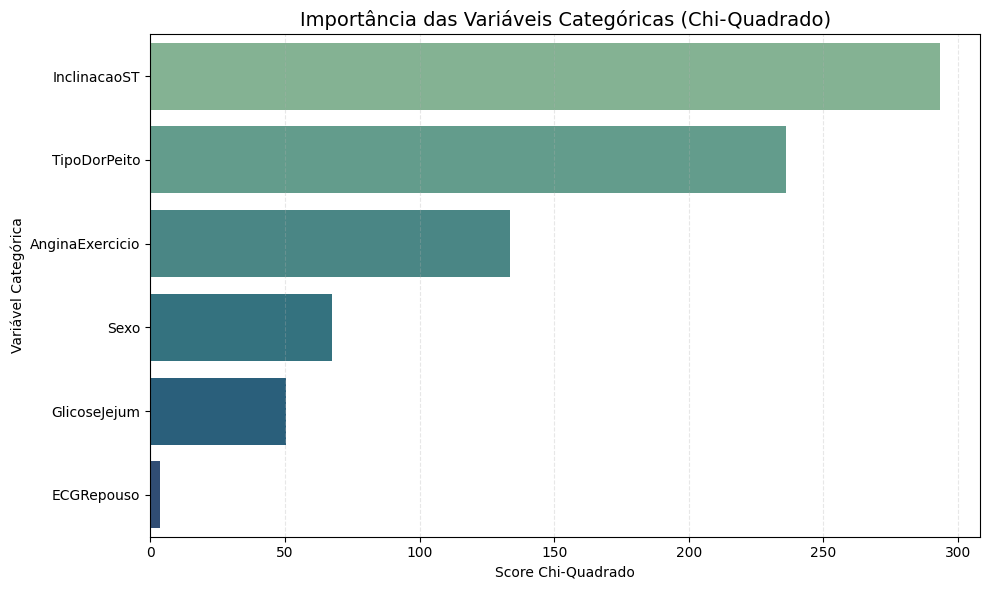

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Geração do gráfico dos resultados das variáveis categóricas
plt.figure(figsize=(10, 6))
sns.barplot(
    x=cat_df['Chi-Quadrado'],
    y=cat_df.index,
    palette="crest"
)
plt.title("Importância das Variáveis Categóricas (Chi-Quadrado)", fontsize=14)
plt.xlabel("Score Chi-Quadrado")
plt.ylabel("Variável Categórica")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

Após criação dos gráficos, podemos verificar que a feature mais relavante, entre as categóricas, é a InclinacaoST.

/tmp/ipython-input-104481853.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


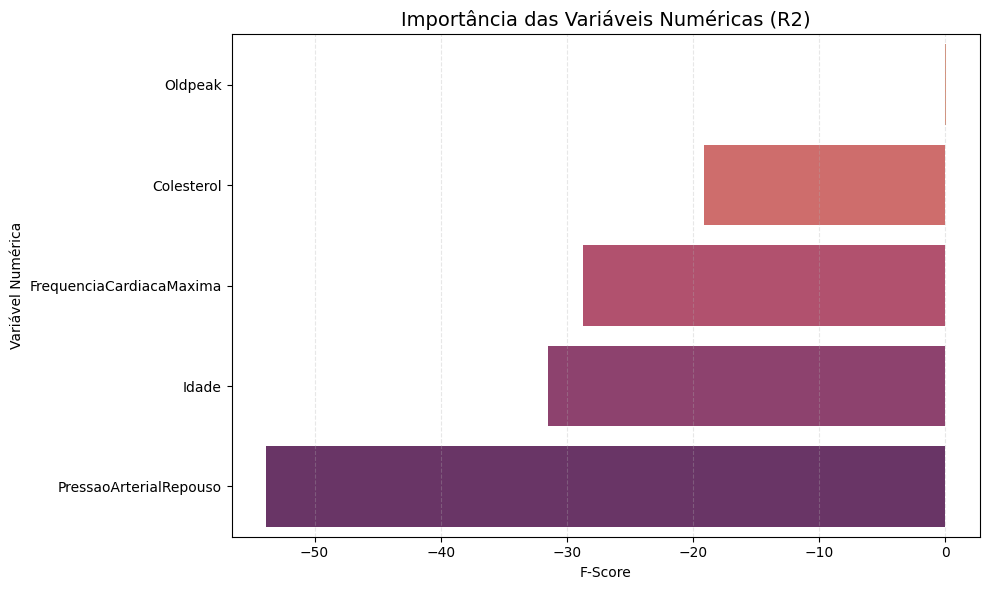

In [ ]:
#Geração do gráfico dos resultados das variáveis numéricas
plt.figure(figsize=(10, 6))
sns.barplot(
    x=num_df['R2'],
    y=num_df.index,
    palette="flare"
)
plt.title("Importância das Variáveis Numéricas (R2)", fontsize=14)
plt.xlabel("F-Score")
plt.ylabel("Variável Numérica")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

Ao utilizar o coeficiente de determinação (R²), observamos que ele não é adequado para o caso em questão, pois não permite a comparação entre variáveis numéricas e categóricas. Para esse tipo de análise, o método mais apropriado é o Teste F, disponível na biblioteca Scikit-Learn (f_classif), que permite avaliar a relação entre variáveis categóricas e o alvo da classificação.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

#Separação do target, variáveis categóricas e numéricas
target = df_pt['DoencaCardiaca']
cat_df = df_pt.drop(columns=['Idade', 'PressaoArterialRepouso', 'Colesterol', 'FrequenciaCardiacaMaxima', 'Oldpeak', 'DoencaCardiaca'])
num_df = df_pt.drop(columns=['Sexo','TipoDorPeito','GlicoseJejum','ECGRepouso','AnginaExercicio','InclinacaoST','DoencaCardiaca'])

#Aplicação do SelectKBest para variáveis:
#Numéricas (f-score)
best_num = SelectKBest(f_classif, k="all")
num_scores = list()
for column in num_df.columns:
  best_num.fit(num_df[[column]], target)
  num_scores.append(best_num.scores_)

#Criação do dataframe de resultados
num_df = pd.DataFrame(num_scores, index=num_df.columns, columns=['F_Score'])
#Ordenando do maior para o menor
num_df = num_df.sort_values(by='F_Score', ascending=False)
#Printando resultados
display(num_df)

,F_Score
Oldpeak,178.615120
FrequenciaCardiacaMaxima,174.913585
Idade,79.160779
PressaoArterialRepouso,12.889725
Colesterol,0.826763


/tmp/ipython-input-562313287.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


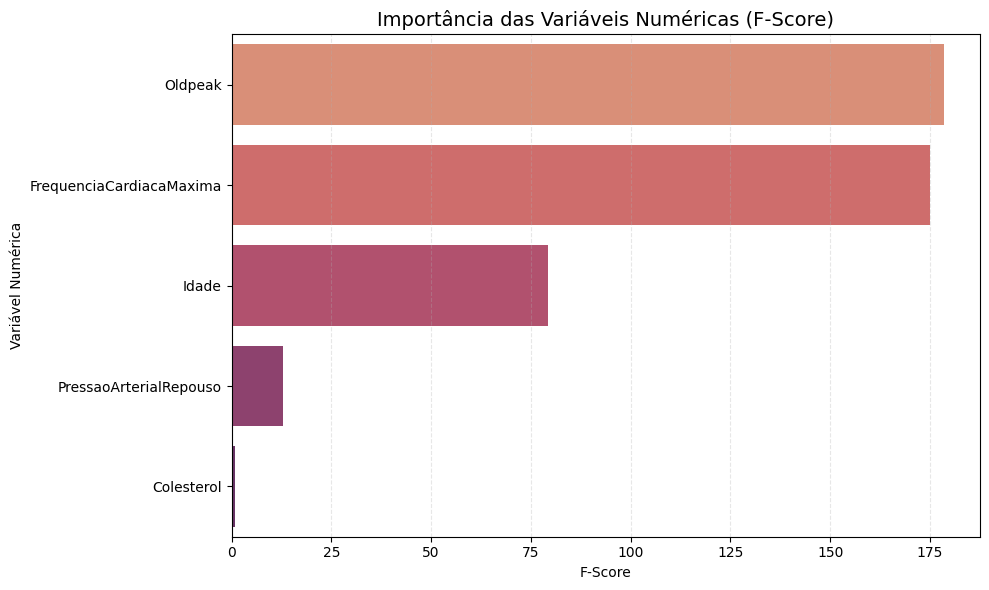

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=num_df['F_Score'],
    y=num_df.index,
    palette="flare"
)
plt.title("Importância das Variáveis Numéricas (F-Score)", fontsize=14)
plt.xlabel("F-Score")
plt.ylabel("Variável Numérica")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

Após correção, podemos verificar que a feature mais relavante, entre as numéricas, é a OldPeak.

#####################################################################################################

#####################################################################################################

#####################################################################################################

# Trabalho Final. Base de Dados: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

In [ ]:
!pip install ucimlrepo

In [ ]:
#Ignorar warning
import warnings
warnings.simplefilter("ignore", DeprecationWarning)

In [ ]:
from ucimlrepo import fetch_ucirepo

#Consulta da Base
default_of_credit_card_clients = fetch_ucirepo(id=350)

#Separação de features e target
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

In [ ]:
import pandas as pd

#Unindo features e target
df_features = pd.DataFrame(X)
df_target = pd.DataFrame(y)
df = pd.concat([df_features, df_target], axis=1)

In [ ]:
#Renomeando colunas
cols_features = {
    "X1":  "valor_credito",
    "X2":  "sexo",
    "X3":  "educacao",
    "X4":  "estado_civil",
    "X5":  "idade_anos",
    "X6":  "status_pag_set_2005",
    "X7":  "status_pag_ago_2005",
    "X8":  "status_pag_jul_2005",
    "X9":  "status_pag_jun_2005",
    "X10": "status_pag_mai_2005",
    "X11": "status_pag_abr_2005",
    "X12": "valor_fatura_set_2005",
    "X13": "valor_fatura_ago_2005",
    "X14": "valor_fatura_jul_2005",
    "X15": "valor_fatura_jun_2005",
    "X16": "valor_fatura_mai_2005",
    "X17": "valor_fatura_abr_2005",
    "X18": "valor_pago_set_2005",
    "X19": "valor_pago_ago_2005",
    "X20": "valor_pago_jul_2005",
    "X21": "valor_pago_jun_2005",
    "X22": "valor_pago_mai_2005",
    "X23": "valor_pago_abr_2005"
}
col_target = {
    "Y": "inadimplente"
}

#Aplicação do rename:
df_features.rename(columns=cols_features, inplace=True)
df_target.rename(columns=col_target, inplace=True)

In [ ]:
#Criação de novas features a partir das colunas status_pag_MÊS_ANO

status_pag_cols = [
    'status_pag_set_2005',
    'status_pag_ago_2005',
    'status_pag_jul_2005',
    'status_pag_jun_2005',
    'status_pag_mai_2005',
    'status_pag_abr_2005'
]

#Total de meses com atraso de pagamento (> 0 significa atraso de 1 mês ou mais)
df_features['num_meses_atrasado'] = (df_features[status_pag_cols] > 0).sum(axis=1).astype(int)

#Maior status (quanto maior, maior o atraso, exc. valores de -1 significado “pagamento em dia”)
df_features['maior_atraso'] = df_features[status_pag_cols].max(axis=1)

#Quantidade de pagamentos efetuados pontualmente (-1 = pagamento em dia)
df_features['qtd_pagamentos_em_dia'] = (df_features[status_pag_cols] == -1).sum(axis=1).astype(int)

In [ ]:
#Criação de novas features a partir das colunas valor_fatura_MES_ANO

valor_fatura_cols = [
    "valor_fatura_set_2005",
    "valor_fatura_ago_2005",
    "valor_fatura_jul_2005",
    "valor_fatura_jun_2005",
    "valor_fatura_mai_2005",
    "valor_fatura_abr_2005",
]

#Média mensal da fatura
df_features["fatura_media"] = df_features[valor_fatura_cols].mean(axis=1)

#Soma total das faturas nos 6 meses
df_features["fatura_total"] = df_features[valor_fatura_cols].sum(axis=1)

#Desvio-padrão das faturas (variação)
df_features["variacao_fatura"] = df_features[valor_fatura_cols].std(axis=1)

#Crescimento entre setembro e abril de 2005
df_features["crescimento_fatura"] = df_features["valor_fatura_set_2005"] - df_features["valor_fatura_abr_2005"]

In [ ]:
#Mais duas features a partir das colunas valor_pago_MES_ANO
#Pagamento total do período e saldo total (diferença entre o que foi pago e o que foi faturado)
pagamento_cols = [
    "valor_pago_abr_2005",
    "valor_pago_mai_2005",
    "valor_pago_jun_2005",
    "valor_pago_jul_2005",
    "valor_pago_ago_2005",
    "valor_pago_set_2005",
]

#Pagamento total no período
df_features["pagamento_total"] = df_features[pagamento_cols].sum(axis=1)

#Saldo total
df_features["saldo_total"] = df_features["pagamento_total"] - df_features["fatura_total"]

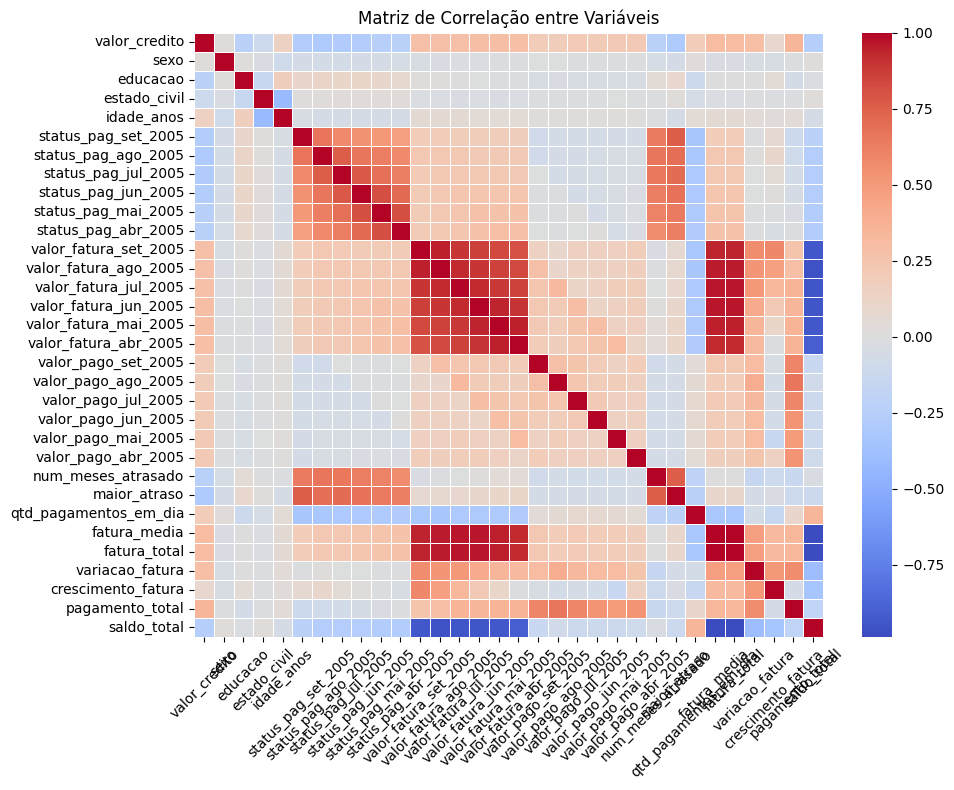

In [ ]:
# Mostrando a matriz de correlação entre as variáveis

# Calcula a matriz de correlação
correlation_matrix = df_features.corr()

# Cria o heatmap com os nomes das variáveis nos eixos
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5,
            xticklabels=correlation_matrix.columns,
            yticklabels=correlation_matrix.columns)
plt.title('Matriz de Correlação entre Variáveis')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Vemos que existe uma vasta gama de colinearidade entre os atributos do tipo "valor_pago" e "status_pag", mostrando que estes não agregarão em nada no modelo, vamos removê-los.

In [ ]:
#Remoção de features (colunas) desnecessárias
cols = [
    "valor_pago_abr_2005",
    "valor_pago_mai_2005",
    "valor_pago_jun_2005",
    "valor_pago_jul_2005",
    "valor_pago_ago_2005",
    "valor_pago_set_2005",
    "status_pag_abr_2005",
    "status_pag_mai_2005",
    "status_pag_jun_2005",
    "status_pag_jul_2005",
    "status_pag_ago_2005",
    "status_pag_set_2005",
    "valor_fatura_set_2005",
    "valor_fatura_ago_2005",
    "valor_fatura_jul_2005",
    "valor_fatura_jun_2005",
    "valor_fatura_mai_2005",
    "valor_fatura_abr_2005"
]

df_features.drop(columns=cols, inplace=True)

## Vamos olhar como ficou a matriz após a deleção

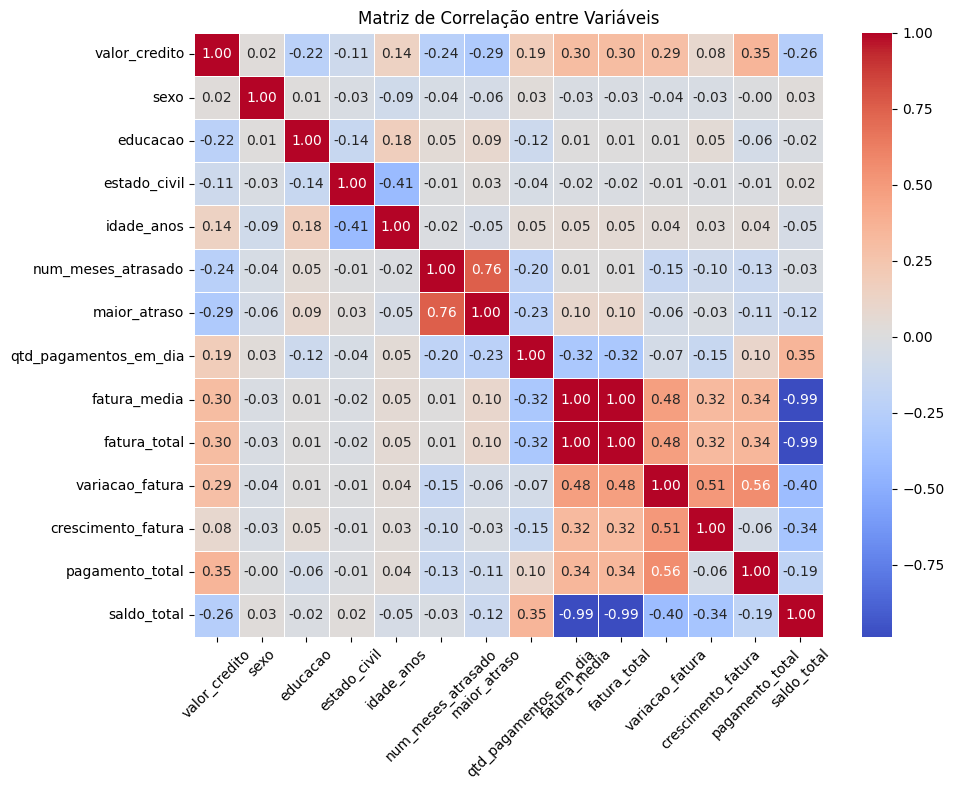

In [ ]:
# Mostrando a matriz de correlação entre as variáveis

# Calcula a matriz de correlação
correlation_matrix = df_features.corr()

# Cria o heatmap com os nomes das variáveis nos eixos
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,
            xticklabels=correlation_matrix.columns,
            yticklabels=correlation_matrix.columns)
plt.title('Matriz de Correlação entre Variáveis')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Melhorou, mas ainda existem fortíssimas colinearidades aqui e ali, como entre $qtd\_pagamentos\_em\_dia$ e $fatura\_total$, que possuem correlação perfeita! Algo claramente está errado, vamos fazer mais algumas análises.

In [ ]:
#Unindo features ao target
df = pd.concat([df_features, df_target], axis=1)

In [ ]:
#Database final
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   valor_credito          30000 non-null  int64  
 1   sexo                   30000 non-null  int64  
 2   educacao               30000 non-null  int64  
 3   estado_civil           30000 non-null  int64  
 4   idade_anos             30000 non-null  int64  
 5   num_meses_atrasado     30000 non-null  int64  
 6   maior_atraso           30000 non-null  int64  
 7   qtd_pagamentos_em_dia  30000 non-null  int64  
 8   fatura_media           30000 non-null  float64
 9   fatura_total           30000 non-null  int64  
 10  variacao_fatura        30000 non-null  float64
 11  crescimento_fatura     30000 non-null  int64  
 12  pagamento_total        30000 non-null  int64  
 13  saldo_total            30000 non-null  int64  
 14  inadimplente           30000 non-null  int64  
dtypes:

In [ ]:
#Removendo números negativos da feature "maior_atraso"
df_features['maior_atraso'] = df_features['maior_atraso'] + 2

df_features['maior_atraso'].unique()

array([ 4,  2,  1,  3,  0,  5,  8,  7,  6, 10,  9])

In [ ]:
#Separação de variaveis qualitatitvas e quantitativas da tabela df_features
cat_df = df_features[['sexo', 'educacao', 'estado_civil']]
num_df = df_features[['maior_atraso', 'valor_credito', 'idade_anos', 'num_meses_atrasado', 'qtd_pagamentos_em_dia', 'fatura_media', 'fatura_total', 'variacao_fatura', 'crescimento_fatura', 'pagamento_total', 'saldo_total']]

In [ ]:
#Verificação das features qualitativas e quantitiativas com o SelectKBest
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import r2_score

#Aplicação do SelectKBest para variáveis:
#Categóricas (Qui-Quadrado)
best_cat = SelectKBest(chi2, k="all")
best_cat.fit(cat_df, df_target)
cat_scores = best_cat.scores_
#Numéricas (R2)
best_num = SelectKBest(r2_score, k="all")
num_scores = list()
for column in num_df.columns:
  best_num.fit(num_df[[column]], df_target)
  num_scores.append(best_num.scores_)

#Criação do dataframe de resultados
cat_df_result = pd.DataFrame(cat_scores, index=cat_df.columns, columns=['Chi-Quadrado'])
num_df_result = pd.DataFrame(num_scores, index=num_df.columns, columns=['R2'])
#Ordenando do maior para o menor
cat_df_result = cat_df_result.sort_values(by='Chi-Quadrado', ascending=False)
num_df_result = num_df_result.sort_values(by='R2', ascending=False)
#Printando resultados
display(cat_df_result, num_df_result)

,Chi-Quadrado
educacao,7.931259
sexo,7.146367
estado_civil,3.120010


,R2
num_meses_atrasado,-0.014084
crescimento_fatura,-0.079081
pagamento_total,-0.270766
qtd_pagamentos_em_dia,-0.316997
variacao_fatura,-0.353910
saldo_total,-0.430257
fatura_media,-0.505501
fatura_total,-0.505505
valor_credito,-1.666337
maior_atraso,-2.608677


### R² é uma métrica que varia de 0 a 1, não possui valores negativos, logo houve algum problema, vamos aplicar uma métrica diferente, a Anova

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

#Aplicação do SelectKBest para variáveis:
#Numéricas (f-score)
best_num = SelectKBest(f_classif, k="all")
num_scores = list()
for column in num_df.columns:
  best_num.fit(num_df[[column]], df_target)
  num_scores.append(best_num.scores_)

#Criação do dataframe de resultados
num_df_result = pd.DataFrame(num_scores, index=num_df.columns, columns=['F_Score'])
#Ordenando do maior para o menor
num_df_result = num_df_result.sort_values(by='F_Score', ascending=False)
#Printando resultados
display(num_df_result)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

,F_Score
num_meses_atrasado,5659.487447
maior_atraso,3691.914796
valor_credito,724.068539
pagamento_total,317.598973
qtd_pagamentos_em_dia,218.022242
variacao_fatura,192.457893
crescimento_fatura,19.748084
idade_anos,5.788556
fatura_media,4.832575
fatura_total,4.832575


### Após análise das variáveis verificamos que as mais importantes, entre as quantitativas foram:
- num_meses_atrasado
- maior_atraso
- valor_credito
- pagamento_total
- qtd_pagamentos_em_dia
- variacao_fatura,

### as demais serão excluídas.

### Quanto às qualitativas serão todas mantidas, assim temos:

In [ ]:
df_features = df_features.drop(
    columns=['crescimento_fatura', 'idade_anos',
             'fatura_media', 'fatura_total', 'saldo_total']
    )

#Unindo features ao target
df = pd.concat([df_features, df_target], axis=1)

#### Vamos checar como ficou a matriz após feito estas mudanças

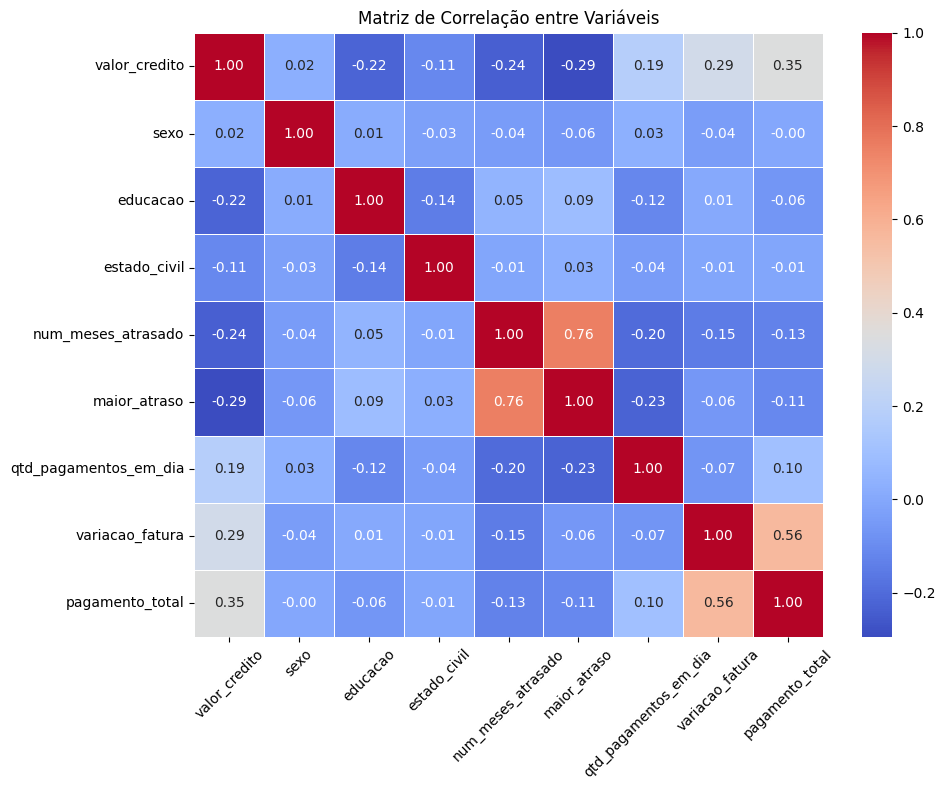

In [ ]:
# Mostrando a matriz de correlação entre as variáveis

# Calcula a matriz de correlação
correlation_matrix = df_features.corr()

# Cria o heatmap com os nomes das variáveis nos eixos
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,
            xticklabels=correlation_matrix.columns,
            yticklabels=correlation_matrix.columns)
plt.title('Matriz de Correlação entre Variáveis')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Ótimo! Chegamos à melhor situação, por mais que ainda existam algumas nuâncias, não são pesadas, podemos trabalhar com isso.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   valor_credito          30000 non-null  int64  
 1   sexo                   30000 non-null  int64  
 2   educacao               30000 non-null  int64  
 3   estado_civil           30000 non-null  int64  
 4   num_meses_atrasado     30000 non-null  int64  
 5   maior_atraso           30000 non-null  int64  
 6   qtd_pagamentos_em_dia  30000 non-null  int64  
 7   variacao_fatura        30000 non-null  float64
 8   pagamento_total        30000 non-null  int64  
 9   inadimplente           30000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 2.3 MB


In [ ]:
# Verificandno balanceamento do target
import numpy as np
print(np.bincount(df_target['inadimplente'].tolist()))

# DESBALANCEADO, usar SMOTE?

[23364  6636]


In [ ]:
############# APLICAÇÃO DO ALGORITMO DE ML (Classificação) #############

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

#Separação features e target
X = df.drop("inadimplente", axis=1)
y = df["inadimplente"]

#Treino e teste (separação)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar modelo de classificação
# model = RandomForestClassifier()
# model = LogisticRegression()
# model = KNeighborsClassifier(n_neighbors=5)
# model = SVC(kernel='rbf')
# model = DecisionTreeClassifier()
model = GradientBoostingClassifier()
# model = GaussianNB()
# model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)

model.fit(X_train, y_train)

#Avaliação
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

#Acurácia
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia no treino: {acc_train:.4f}")
print(f"Acurácia no teste: {acc_test:.4f}\n")

#Relatório de classificação (somente para o teste)
print("Relatório de classificação (teste):")
print(classification_report(y_test, y_pred_test))

Acurácia no treino: 0.8094
Acurácia no teste: 0.8060

Relatório de classificação (teste):
              precision    recall  f1-score   support

           0       0.83      0.95      0.88      4687
           1       0.62      0.30      0.40      1313

    accuracy                           0.81      6000
   macro avg       0.72      0.62      0.64      6000
weighted avg       0.78      0.81      0.78      6000



In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_test)
print(f"Acurácia Teste: {accuracy:.2%}")

Acurácia Teste: 80.60%


              precision    recall  f1-score   support

           0       0.83      0.95      0.88      4687
           1       0.62      0.30      0.40      1313

    accuracy                           0.81      6000
   macro avg       0.72      0.62      0.64      6000
weighted avg       0.78      0.81      0.78      6000

Matriz de Confusão:
 [[4446  241]
 [ 923  390]]


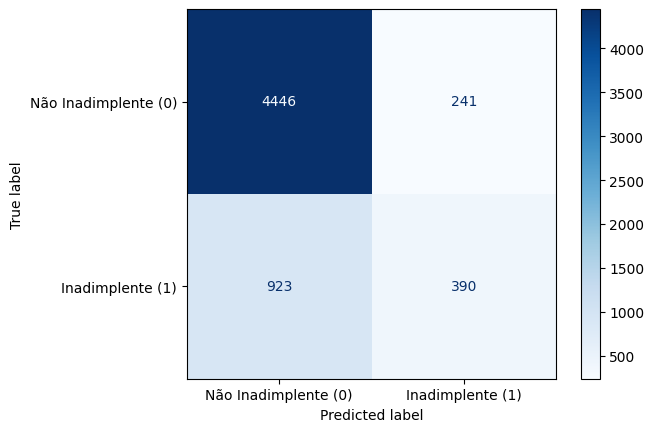

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Relatório completo
print(classification_report(y_test, y_pred_test))

#Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_test)
print("Matriz de Confusão:\n", cm)

#Gráfico da Matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Não Inadimplente (0)", "Inadimplente (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
#Teste do modelo com exemplo imputado pelo usuário, para verificação de encaixe no perfil de inadimplente:
#sexo: 2 (feminino)
#educacao: 2 (universitário)
#estado_civil: 2 (solteiro)
#num_meses_atrasado: 3
#maior_atraso: 4 (maior número de meses em atraso)
#qtd_pagamentos_em_dia: 5
#variacao_fatura: 150.5
#pagamento_total: 4000
#valor_credito: 20000

#Exemplo de cliente com características específicas
cliente_exemplo = [[2, 2, 2, 3, 4, 5, 150.5, 4000, 20000]]

#Previsão se inadimplente
previsao = model.predict(cliente_exemplo)
if previsao[0] == 0:
  print("Cliente se encaixa no perfil de NÃO INADIMPLENTE.\n\n")
else:
  print("Cliente se encaixa no perfil de INADIMPLENTE.\n\n")

Cliente se encaixa no perfil de INADIMPLENTE.




/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#Exemplo de cliente com características específicas
cliente_exemplo = [[2, 2, 2, 0, 1, 5, 150.5, 4000, 20000]]

#Previsão se inadimplente
previsao = model.predict(cliente_exemplo)
if previsao[0] == 0:
  print("Cliente se encaixa no perfil de NÃO INADIMPLENTE.\n\n")
else:
  print("Cliente se encaixa no perfil de INADIMPLENTE.\n\n")

Cliente se encaixa no perfil de NÃO INADIMPLENTE.




/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
